In [1]:
import pandas as pd
import numpy as np
import os

# Define the directory where your files are located
# os.path.expanduser('~') automatically finds your Mac's /Users/yourusername/ folder
base_path = os.path.expanduser('~/Desktop/ie0005/archive1/')

# List of files to process as provided in your directory
files = [
    'BeijingPM20100101_20151231.csv',
    'ChengduPM20100101_20151231.csv',
    'GuangzhouPM20100101_20151231.csv',
    'ShanghaiPM20100101_20151231.csv',
    'ShenyangPM20100101_20151231.csv'
]

def clean_city_data(file_name):
    # Construct the full file path
    full_path = os.path.join(base_path, file_name)
    
    print(f"Processing: {file_name}...")
    
    # 1. LOAD DATA
    # We load the CSV and identify 'NA' strings as actual Null values (NaN)
    df = pd.read_csv(full_path, na_values=['NA', 'NaN', ' '])
    
    # 2. CREATE DATETIME INDEX
    # We combine the 4 separate time columns into a single 'datetime' object.
    # This allows for easy time-series filtering and plotting.
    df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
    df.set_index('datetime', inplace=True)
    
    # 3. CALCULATE UNIFIED PM AVERAGE
    # Each city has different station names (e.g., PM_Xuhui, PM_US Post).
    # We find all columns starting with 'PM_' and calculate their average for that hour.
    pm_cols = [col for col in df.columns if col.startswith('PM_')]
    df['PM_Average'] = df[pm_cols].mean(axis=1)
    
    # 4. TEMPORAL INTERPOLATION
    # If a sensor was down for 1-6 hours, we fill the gap with a linear trend.
    # We limit this to 6 hours to prevent creating "fake" data for long outages.
    df['PM_Average'] = df['PM_Average'].interpolate(method='linear', limit=6)
    
    # 5. REMOVE REDUNDANT COLUMNS
    # 'No' is just an index, and year/month/day/hour are now part of our index.
    # We drop them to keep the file size small and the data clean.
    cols_to_drop = ['No', 'year', 'month', 'day', 'hour']
    df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)
    
    # 6. HANDLE WEATHER DATA & FINAL MISSING ROWS
    # We identify weather columns. If these are missing, the row is usually unusable.
    weather_cols = ['DEWP', 'HUMI', 'PRES', 'TEMP', 'Iws', 'precipitation', 'Iprec']
    existing_weather = [c for c in weather_cols if c in df.columns]
    
    # We drop any remaining rows that don't have a PM_Average or Weather data.
    df.dropna(subset=['PM_Average'] + existing_weather, inplace=True)
    
    # 7. SAVE CLEANED DATA
    # We save the file back to the same folder with the 'cleaned_' prefix.
    output_file_name = 'cleaned_' + file_name
    output_path = os.path.join(base_path, output_file_name)
    df.to_csv(output_path)
    
    print(f"Successfully saved to: {output_file_name}")
    print(f"Final Row Count: {len(df)}\n")

# Run the cleaning loop for all files
for file in files:
    try:
        clean_city_data(file)
    except Exception as e:
        print(f"Error processing {file}: {e}")

print("All cleaning tasks completed.")

Processing: BeijingPM20100101_20151231.csv...
Successfully saved to: cleaned_BeijingPM20100101_20151231.csv
Final Row Count: 50320

Processing: ChengduPM20100101_20151231.csv...
Successfully saved to: cleaned_ChengduPM20100101_20151231.csv
Final Row Count: 29050

Processing: GuangzhouPM20100101_20151231.csv...
Successfully saved to: cleaned_GuangzhouPM20100101_20151231.csv
Final Row Count: 33673

Processing: ShanghaiPM20100101_20151231.csv...
Successfully saved to: cleaned_ShanghaiPM20100101_20151231.csv
Final Row Count: 32674

Processing: ShenyangPM20100101_20151231.csv...
Successfully saved to: cleaned_ShenyangPM20100101_20151231.csv
Final Row Count: 24749

All cleaning tasks completed.


--- Data Quality and Statistical Review ---

Reviewing Beijing: 50320 rows found. Quality Check: PASS
Reviewing Chengdu: 29050 rows found. Quality Check: PASS
Reviewing Guangzhou: 33673 rows found. Quality Check: PASS
Reviewing Shanghai: 32674 rows found. Quality Check: PASS
Reviewing Shenyang: 24749 rows found. Quality Check: PASS

--- Comparative City Statistics ---
     City  Total Rows  Mean PM2.5  Max PM2.5  Std Dev  Missing Values
  Beijing       50320       95.07     994.00    90.45               0
  Chengdu       29050       81.32     600.67    57.77               0
Guangzhou       33673       51.05     387.00    35.44               0
 Shanghai       32674       55.01     730.00    45.02               0
 Shenyang       24749       78.12    1065.50    72.79               0


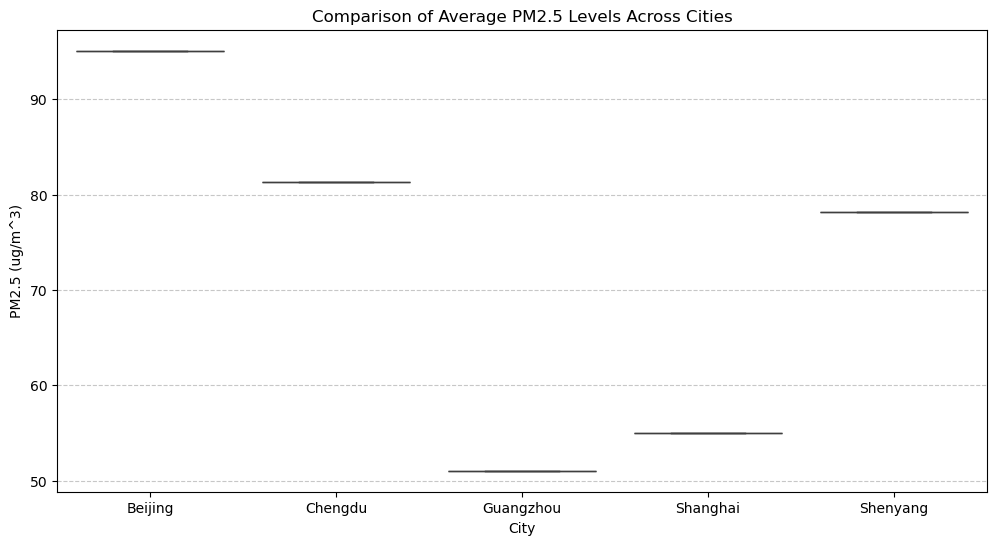

In [6]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Path to your cleaned data
base_path = os.path.expanduser('~/Desktop/ie0005/archive1/')
cleaned_files = [
    'cleaned_BeijingPM20100101_20151231.csv',
    'cleaned_ChengduPM20100101_20151231.csv',
    'cleaned_GuangzhouPM20100101_20151231.csv',
    'cleaned_ShanghaiPM20100101_20151231.csv',
    'cleaned_ShenyangPM20100101_20151231.csv'
]

# Initialize a list to store summary data
summary_list = []

print("--- Data Quality and Statistical Review ---\n")

for file in cleaned_files:
    full_path = os.path.join(base_path, file)
    
    if os.path.exists(full_path):
        # Load the cleaned file
        df = pd.read_csv(full_path)
        city_name = file.replace('cleaned_', '').split('PM')[0]
        
        # 1. Statistical Summary for PM_Average
        stats = df['PM_Average'].describe()
        
        # 2. Check for remaining NaNs (Should be 0)
        null_count = df['PM_Average'].isnull().sum()
        
        # Store results for a comparison table
        summary_list.append({
            'City': city_name,
            'Total Rows': len(df),
            'Mean PM2.5': round(stats['mean'], 2),
            'Max PM2.5': round(stats['max'], 2),
            'Std Dev': round(stats['std'], 2),
            'Missing Values': null_count
        })
        
        print(f"Reviewing {city_name}: {len(df)} rows found. Quality Check: {'PASS' if null_count == 0 else 'FAIL'}")

# Create a clean comparison table
summary_df = pd.DataFrame(summary_list)
print("\n--- Comparative City Statistics ---")
print(summary_df.to_string(index=False))

# 3. Visual Review: Distribution of Air Quality across cities
plt.figure(figsize=(12, 6))
sns.boxplot(x='City', y='Mean PM2.5', data=summary_df) # Note: Comparing the means of the datasets
plt.title('Comparison of Average PM2.5 Levels Across Cities')
plt.ylabel('PM2.5 (ug/m^3)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()